# Day 91 - Descriptive Statistics (Mean, Median & Mode)
Descriptive statistics helps us summarize large datasets into meaningful insights by answering questions such as:
- What is the average value?
- What is the middle value?
- Which value occurs most frequently?
- How is the data distributed?
- Are there any unusual or extreme values?

# 

## Business Problem

A school wants to analyze students' marks to understand their overall academic performance.

The school needs to:
- Find the average marks of students.
- Identify the most common marks.
- Detect unusual or extreme scores.

In [2]:
import pandas as pd   #----- Data Manipulation
import numpy as np    #----- Numerical Operations
import matplotlib.pyplot as plt # --- Data Visualization
import seaborn as sns

In [5]:
# Set Seaborn theme for better visualization
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("student_scores.csv")

In [7]:
df.head()

,StudentID,Name,Math,Science,English,Attendance
0,1,Student_1,49,38,70,77
1,2,Student_2,63,52,48,91
2,3,Student_3,46,89,39,70
3,4,Student_4,46,62,64,86
4,5,Student_5,38,60,88,77


In [8]:
df.shape

(500, 6)

In [10]:
df.isnull().sum()

StudentID     0
Name          0
Math          0
Science       0
English       0
Attendance    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudentID   500 non-null    int64 
 1   Name        500 non-null    object
 2   Math        500 non-null    int64 
 3   Science     500 non-null    int64 
 4   English     500 non-null    int64 
 5   Attendance  500 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 23.6+ KB


In [15]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,500.0,250.500,144.481833,1.0,125.75,250.5,375.25,500.0
Math,500.0,67.404,18.880194,35.0,51.00,67.0,83.00,100.0
Science,500.0,67.206,18.899257,35.0,50.00,68.0,83.00,100.0
English,500.0,69.318,19.004083,35.0,53.00,71.0,86.25,100.0
Attendance,500.0,85.718,8.703907,70.0,78.00,86.0,93.00,100.0


# 

In [16]:
mean_scores = df[['Math', 'Science', 'English']].mean()

In [18]:
print("Average Marks in Each Subject")
mean_scores

Average Marks in Each Subject


Math       67.404
Science    67.206
English    69.318
dtype: float64

###### Observation
- The Mean represents the average marks scored by students.
- It provides a quick overview of overall class performance.

# 

###### Median
The **Median** is the middle value after arranging the data in ascending order.


In [20]:
# Calculate median for all subjects
median_scores = df[['Math', 'Science', 'English']].median()

In [21]:
print("Median Marks in Each Subject")
median_scores

Median Marks in Each Subject


Math       67.0
Science    68.0
English    71.0
dtype: float64

###### Observation
- The Median represents the middle score of the dataset.
- It is useful when the dataset contains unusually high or low values.
- Mean and Median is almost same
  

# 

###### Some Prcatice Questions:

#### Q. Which subject has the highest average marks?

In [23]:
avg_marks = df[['Math','Science', 'English']].mean()
max_avg_sub = avg_marks.idxmax()
max_avg_value = avg_marks.max()

In [24]:
max_avg_sub

'English'

In [25]:
max_avg_value

69.318

#### Q. Which students scored above the average in Math?

In [27]:
math_avg = df['Math'].mean()

In [32]:
df.loc[df['Math']>math_avg,['Name','Math']].head(10)

,Name,Math
5,Student_6,92
9,Student_10,79
10,Student_11,93
11,Student_12,72
13,Student_14,72
15,Student_16,81
18,Student_19,83
19,Student_20,76
22,Student_23,98
23,Student_24,68


#### Q. How many students scored below the average in Science?

In [36]:
df.loc[df['Math']<math_avg,['Name','Math']].shape[0]

252

#### Q. Which students scored above the Median in English?

In [38]:
eng_median = df['English'].median()
df.loc[df['English']>eng_median,['Name','English']].head(10)

,Name,English
4,Student_5,88
6,Student_7,78
7,Student_8,78
10,Student_11,83
15,Student_16,82
20,Student_21,86
21,Student_22,75
22,Student_23,93
24,Student_25,86
25,Student_26,100


#### Q. How many students scored below the Median in Math?

In [41]:
math_median = df['Math'].median()
df.loc[df['Math']<math_median,['Name','Math']].shape[0]

244

#### Q. Compare the Mean and Median of each subject. What do you observe?

In [42]:
comparison = pd.DataFrame({"Mean": df[["Math", "Science", "English"]].mean(), 
                           "Median": df[["Math", "Science", "English"]].median()
                          })

In [43]:
comparison

,Mean,Median
Math,67.404,67.0
Science,67.206,68.0
English,69.318,71.0


In [44]:
# Adding Difference
comparison["Difference"] = comparison["Mean"] - comparison["Median"]

In [45]:
comparison

,Mean,Median,Difference
Math,67.404,67.0,0.404
Science,67.206,68.0,-0.794
English,69.318,71.0,-1.682


###### Math: Difference = +0.404 → Very slight right skew (approximately symmetric).
###### Science: Difference = −0.794 → Very slight left skew (close to symmetric).
###### English: Difference = −1.682 → Slight left skew (not strongly skewed).

- Difference ≈ 0 → Mean and  Median almost same → Data approximately normal/symmetric.
- Mean > Median → Positive (Right) Skew.
- Mean < Median → Negative (Left) Skew.
-
- Difference = 0 to ±1 → Approximately symmetric
- Difference = ±1 to ±3 → Slightly skewed
- Difference = ±3 to ±5 → Moderately skewed
- Difference > ±5 → Highly skewed

# 

#### Q. Find the Mode of Math marks.

In [46]:
df['Math'].mode()

0    59
1    91
Name: Math, dtype: int64

- 59 appears the maximum number of times.
- 91 also appears the same maximum number of times.

# 

#### Q. Find the Mode of Science marks.

In [48]:
df['Science'].mode()

0    40
1    70
Name: Science, dtype: int64

# 

#### Q. Find the Mode of English marks.

In [49]:
df['English'].mode()

0    97
Name: English, dtype: int64

# 

#### Q. Does every subject have a Mode? Explain your answer.

In [53]:
subjects = ["Math", "Science", "English"]

for subject in subjects:
    mode = df[subject].mode()

    print(subject)
    print(mode)
    print(f"Number of Mode(s): {len(mode)}")

Math
0    59
1    91
Name: Math, dtype: int64
Number of Mode(s): 2
Science
0    40
1    70
Name: Science, dtype: int64
Number of Mode(s): 2
English
0    97
Name: English, dtype: int64
Number of Mode(s): 1


 - One value occurs most frequently → Unimodal (one mode).
- Multiple values occur with the same highest frequency → Multimodal (two modes = Bimodal).
- All values occur only once → No unique mode; Pandas returns all values since they have the same frequency.

# 

#### Q. Which subject has the best overall student performance based on the Mean?

In [54]:
mean_scores

Math       67.404
Science    67.206
English    69.318
dtype: float64

In [55]:
best_subject = mean_scores.idxmax()

In [56]:
best_subject

'English'

# 

#### Q. Which subject appears to be most difficult for students?

In [57]:
difficult_subject = mean_scores.idxmin()

In [58]:
difficult_subject

'Science'

# 

#### Q. Which students are performing above average in all three subjects?

In [59]:
mean_scores

Math       67.404
Science    67.206
English    69.318
dtype: float64

In [63]:
top_performing_st =  df[(df["Math"] > mean_scores['Math']) &  (df["Science"] >  mean_scores['Math']) &  (df["English"] >  mean_scores['Math'])]

In [64]:
top_performing_st

,StudentID,Name,Math,Science,English,Attendance
22,23,Student_23,98,85,93,74
24,25,Student_25,68,89,86,81
42,43,Student_43,74,86,82,84
59,60,Student_60,87,97,96,76
62,63,Student_63,93,71,89,92
...,...,...,...,...,...,...
476,477,Student_477,86,73,93,72
488,489,Student_489,98,74,98,70
494,495,Student_495,68,81,86,81
497,498,Student_498,84,99,92,94


# 

#### Visualization Practice Questions

##### Q1. Create a Histogram for Math Marks

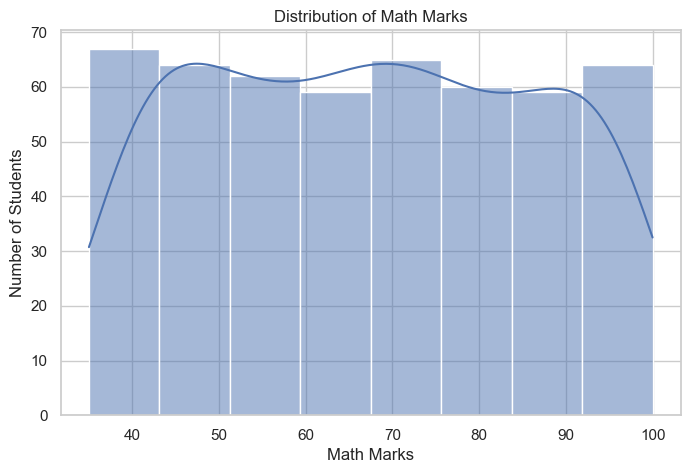

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Math", bins=8, kde=True)
plt.title("Distribution of Math Marks")
plt.xlabel("Math Marks")
plt.ylabel("Number of Students")
plt.show()

- distribution looks balanced

##### Q2. Create a Histogram for Science Marks

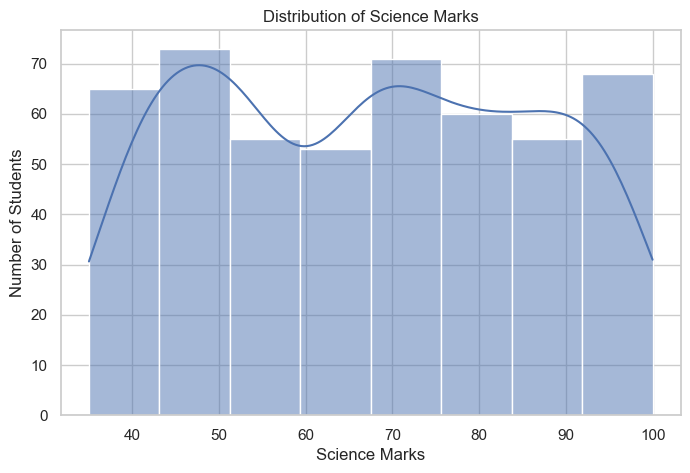

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Science", bins=8, kde=True)
plt.title("Distribution of Science Marks")
plt.xlabel("Science Marks")
plt.ylabel("Number of Students")
plt.show()

 - multiple peak

# 

##### Q3. Create a Histogram for English Marks

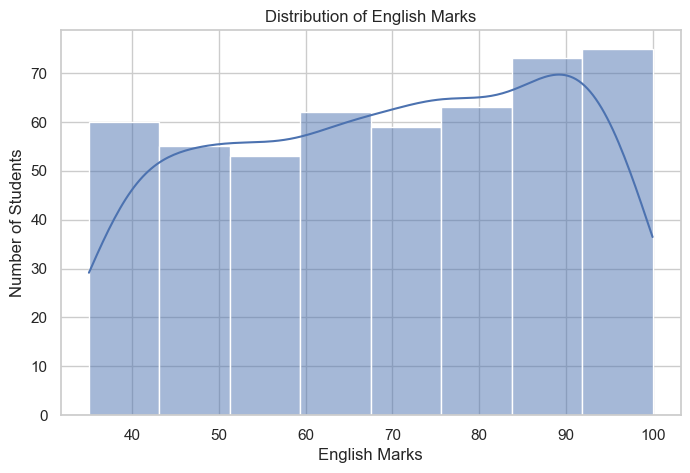

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="English", bins=8, kde=True)
plt.title("Distribution of English Marks")
plt.xlabel("English Marks")
plt.ylabel("Number of Students")
plt.show()

##### Q4. Compare All Subjects Using Box Plot

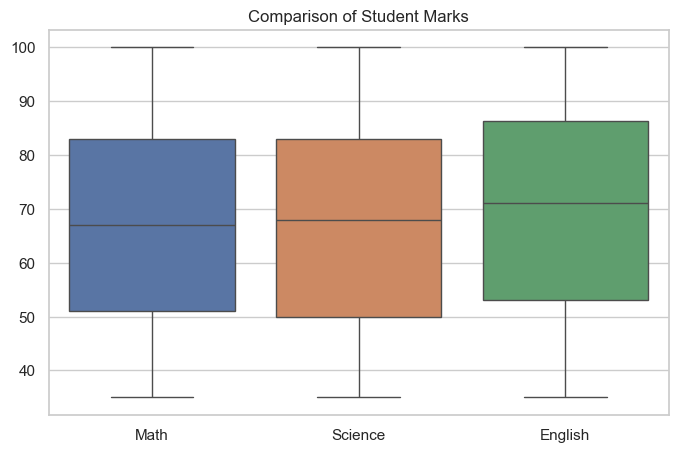

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Math','Science','English']])
plt.title("Comparison of Student Marks")
plt.show()

##### Q5. Find Outliers in Math

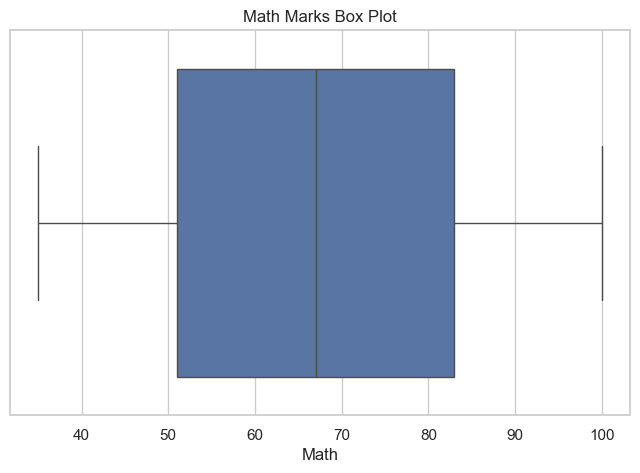

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Math"])
plt.title("Math Marks Box Plot")
plt.show()

##### Q6. Average Marks of Each Subject

In [86]:
average_marks = mean_scores.reset_index()
average_marks.columns = ['Subject','Average Marks']
average_marks

,Subject,Average Marks
0,Math,67.404
1,Science,67.206
2,English,69.318


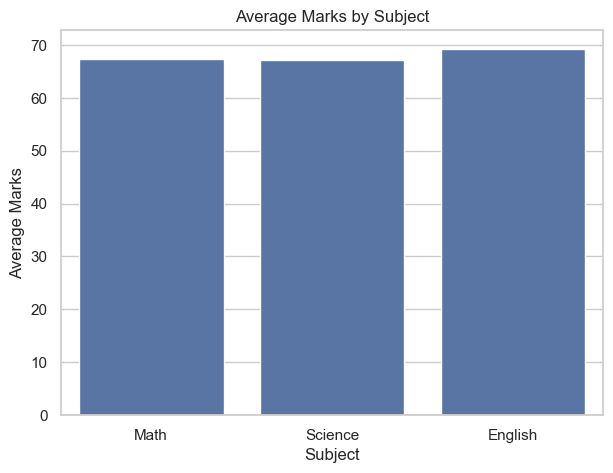

In [89]:
plt.figure(figsize=(7,5))
sns.barplot(data=average_marks,x='Subject',y='Average Marks')
plt.title("Average Marks by Subject")
plt.show()